In [2]:
from sklearn.decomposition import PCA
import umap
import numpy as np
import os
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
from data.utils import get_path

In [3]:
save_dir_root = os.path.join(get_path(), 'grid_cells/')

In [6]:
a = np.load(os.path.join(save_dir_root, "grid_cells_4800.npz"))
data = a['data'] # 6D PCA of spikes
xx = a['xx'] # x coordinate of mouse
yy = a['yy'] # y coordinate of mouse
aa = a['aa'] # head direction
tt = a['tt'] # time point
evecs = a['evecs'] # first 6 PCs
spikes = a['spikes'] # firing rate fo all 149 neurons during all 4800 time points

In [7]:
print(data.shape)
print(xx.shape)
print(yy.shape)
print(aa.shape)
print(tt.shape)
print(evecs.shape)
print(spikes.shape)

(4800, 6)
(4800,)
(4800,)
(4800,)
(4800,)
(149, 6)
(4800, 149)


In [8]:
pca = PCA(2).fit_transform(data)

In [ ]:
embedder = umap.UMAP(n_neighbors=800, n_components=3, metric='cosine', min_dist=0.8, random_state=2)
umap_embedding = embedder.fit_transform(data)

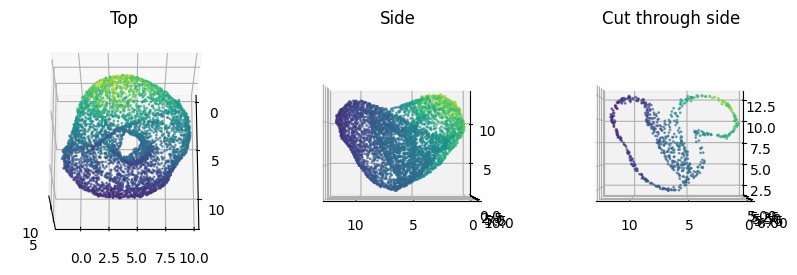

In [10]:
# self-intersecting 3D torus with UMAP
fig, ax = plt.subplots(1, 3, figsize=(10, 6), subplot_kw={"projection": "3d"})

elevs = [70, 0, 0]
azims = [0, 90, 90]

labels = ["Top", "Side", "Cut through side"]

for i in range(3):

    mask = np.ones(len(umap_embedding), dtype=bool)
    if i > 1:
        mask = (umap_embedding[:, 1] >5) * (umap_embedding[:, 1] < 6)

    ax[i].scatter(
        umap_embedding[mask, 0], umap_embedding[mask, 1],umap_embedding[mask, 2], c=pca[mask, 0],
        s=1,          # marker size
        alpha=0.6
    )
    ax[i].view_init(elev=elevs[i], azim=azims[i])
    ax[i].set_title(labels[i])

In [15]:
cell_ids = [
    #5, 39,
    75, 109, 115] # cells with clearly structured firing pattern

Text(0.5, 0.98, 'Firing rates of selected cells by spatial position')

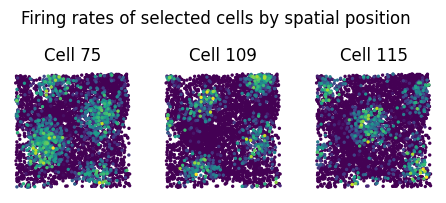

In [19]:
# spatial location of firing rates
fig, ax = plt.subplots(1, 3, figsize=(5.5, 2.5))

for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    ax[i].scatter(xx[order], yy[order], c=spikes[order, idx], s=2)
    ax[i].set_title(f"Cell {idx}")
    ax[i].axis("off")
    ax[i].set_aspect("equal")
fig.suptitle("Firing rates of selected cells by spatial position")

Text(0.5, 0.98, 'Firing rates of selected cells on torus')

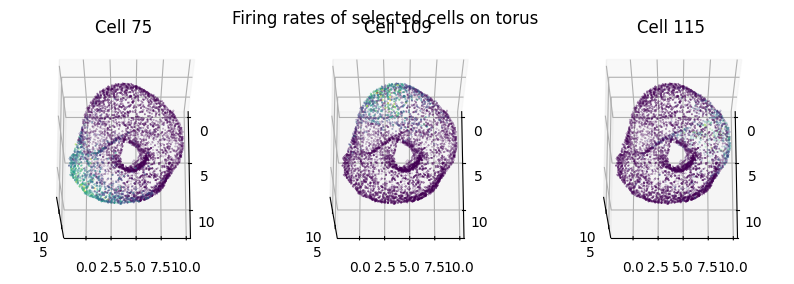

In [21]:
# location of firing rates on torus
fig, ax = plt.subplots(1, 3, figsize=(10, 3), subplot_kw={"projection": "3d"})

elev = 70
azim = 0

for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    ax[i].scatter(*umap_embedding[order].T, c=spikes[order, idx], s=0.1)
    ax[i].set_title(f"Cell {idx}")
    #ax[i].axis("off")
    ax[i].set_aspect("equal")
    ax[i].view_init(elev=elev, azim=azim)
fig.suptitle("Firing rates of selected cells on torus")